### 引言：注意力机制的起源与动机

在深度学习发展的早期，循环神经网络（RNN）及其变体（LSTM、GRU）是处理序列数据的主流方法。然而，这些模型面临着几个根本性的挑战：

1. 长距离依赖问题
RNN通过隐状态 传递信息，但随着序列长度增加，早期信息会逐渐衰减；
即使LSTM引入了门控机制，对于超过100-200个时间步的依赖关系，信息传递仍然困难。Bengio等人(1994)的研究表明，梯度在长序列中会指数级衰减或爆炸。

2. 固定长度瓶颈
在Seq2Seq模型中，编码器将整个输入序列压缩为一个固定长度的向量，这个向量需要承载所有源序列的信息，对于长序列来说是一个严重的信息瓶颈。Cho等人(2014)的实验表明，随着句子长度增加，翻译质量显著下降。

3. 顺序计算限制
RNN必须按时间步顺序计算，无法并行化，这导致训练效率低下，难以利用现代GPU的并行计算能力。

注意力机制的诞生，正是为了打破RNN的“信息瓶颈”和“健忘”困境。它不再强迫模型将所有信息压缩到一个向量中，而是赋予模型一种“回头看”的能力。
其核心思想是：模型在生成当前输出时，可以有选择地、动态地关注输入序列中的不同部分。
这个过程可以类比为人类翻译长句：你不会只靠记忆中的“一句话摘要”来翻译，而是会不断回看原文，根据当前正在翻译的词语，去寻找原文中最相关的部分。

注意力机制的工作机制：
1. 保留全部记忆：
编码器（Encoder）不再只输出最后一个隐藏状态，而是保留所有时间步的隐藏状态 [h₁, h₂, ..., hₙ]，形成一个完整的“记忆库”。
2. 动态计算权重：
当解码器（Decoder）要生成下一个词时，它会根据自己的当前状态（作为“查询”Query），去和编码器的所有隐藏状态（作为“键”Key）进行匹配，计算出一组注意力权重。这些权重代表了输入序列中每个词对生成当前输出词的重要性。
3. 生成上下文向量：
根据计算出的权重，对所有感觉输入（作为“值”Value）进行加权求和，得到一个上下文向量（Context Vector）。这个向量是针对当前生成步骤“量身定制”的，包含了此刻最需要的信息。
4. 辅助生成输出：
解码器结合这个上下文向量和自身的状态（qurey）来生成最终的输出词。
通过这种方式，注意力机制让模型能够直接访问原始输入的任何部分，无论距离多远，从而完美解决了长距离依赖问题。

![注意力机制](./PPT-figure/注意力机制.png)

### 通过Nadaraya-Watson 核回归来理解注意力机制

本节通过Nadaraya-Watson 核回归理解注意力机制，我们先回顾注意力机制有哪些重要组件：
1. key-value键值对：这是非意志线索，可以理解为“与当前信息无关”的信息；
2. qurey查询：这是意志线索，即根据当前情况得到的信息。

在进行回归分析时，我们可以把所有的“输入-输出对”理解为非意志线索，它们一直在那里；
如果不考虑当前信息进行回顾（也就是没有注意力机制），所得到的回归结果就是一个单纯的平均回归：

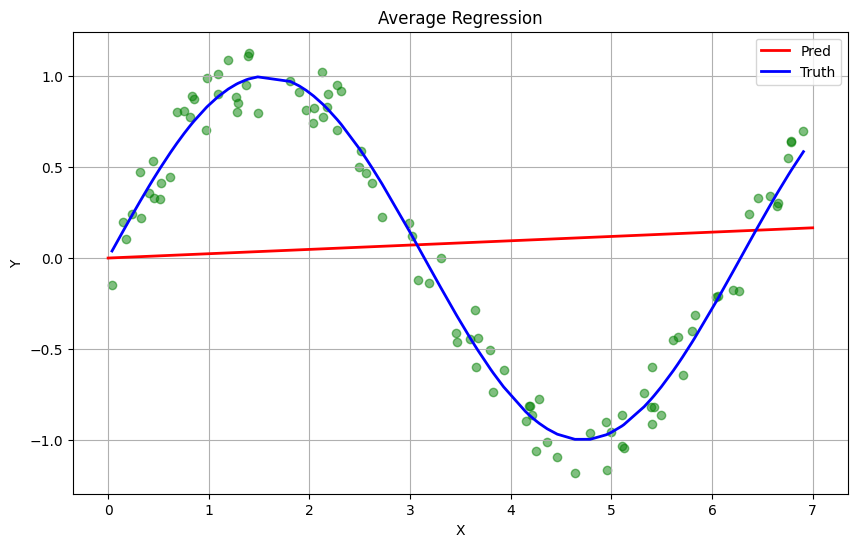

回归方程: y = 0.02 * x


In [29]:
# 平均回归
import numpy as np
import matplotlib.pyplot as plt

# 1. 准备数据
# 生成一些带有噪声的线性数据
np.random.seed(42)
X = np.sort(7 * np.random.rand(100, 1), axis=0)
y = np.sin(X) + (2 * np.random.rand(100, 1) - 1) / 5

# 2. 创建并训练模型
k = np.mean(y) / np.mean(X)

# 3. 进行预测 (用于绘制平滑的回归线)
X_new = np.linspace(0, 7, 100).reshape(-1, 1)
y_predict = k * (X_new)

# 4. 画图展示
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='green', alpha=0.5)
plt.plot(X_new, y_predict, color='red', linewidth=2, label='Pred')
plt.plot(X, np.sin(X), color='blue', linewidth=2, label='Truth')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Average Regression")
plt.legend()
plt.grid(True)
plt.show()

# 打印模型参数
print(f"回归方程: y = {k:.2f} * x")

这种回归方式忽略了x与y的对应关系，只反映了**每个y都同样重要**，忽略了**局部信息**。
在注意力机制中，y提供的信息可以理解为非意志线索，而x与y的位置对应关系则是局部线索。
因此，Nadaraya-Watson 核回归利用到了这些局部信息，也就是qurey。

Nadaraya-Watson 核回归的核心思想是：对于要预测所对应值的x，重点考虑距离这个x较近的训练数据，它们的权重更高。

也就是说，通过qurey（x），与x位置更接近的这些键值对有更高的权重。这就是注意力机制的核心思想：通过qurey判断全局信息的重要程度。在这个例子里，“位置关系”是qurey所判断的重点。

Nadaraya-Watson 核回归就是加权回归，只是引入了核函数。
核函数决定了如何计算“亲近程度”。最常用的核函数是高斯核（Gaussian Kernel），它基于距离呈指数级衰减，非常符合“远亲不如近邻”的直觉。
高斯核公式: K(x, xᵢ) = exp(-(x - xᵢ)² / (2σ²))
这里的 σ (sigma) 控制着核函数的“胖瘦”，也就是影响范围。

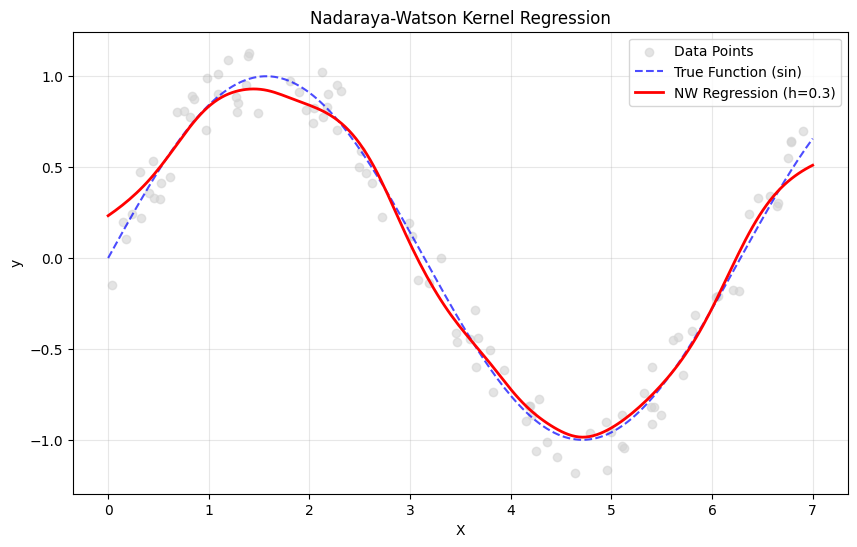

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 准备数据 (直接使用你提供的数据生成代码)
np.random.seed(42)
X_train = np.sort(7 * np.random.rand(100, 1), axis=0)
y_train = np.sin(X_train) + (2 * np.random.rand(100, 1) - 1) / 5

# ---------------------------------------------------------
# 2. 定义 Nadaraya-Watson 核回归类
# ---------------------------------------------------------
class NadarayaWatsonRegressor:
    def __init__(self, bandwidth=0.5, kernel='gaussian'):
        """
        初始化模型
        :param bandwidth: 带宽 (h)，控制平滑程度。越小越贴合数据，越大越平滑。
        :param kernel: 核函数类型，目前支持 'gaussian' (高斯) 和 'uniform' (均匀)
        """
        self.bandwidth = bandwidth
        self.kernel = kernel
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        训练模型（对于核回归来说，其实就是记住训练数据，即“懒惰学习”）
        """
        self.X_train = X
        self.y_train = y

    def _compute_weights(self, X_test_point):
        """
        计算测试点与所有训练点的权重
        """
        # 计算距离：|X_test - X_train|
        distances = np.abs(self.X_train - X_test_point)
        
        # 归一化距离 u = distance / bandwidth
        u = distances / self.bandwidth

        if self.kernel == 'gaussian':
            # 高斯核函数: K(u) = exp(-0.5 * u^2)
            # 忽略常数系数，因为它会在归一化时约掉
            weights = np.exp(-0.5 * u**2)
            
        elif self.kernel == 'uniform':
            # 均匀核（方波）: 如果 |u| <= 1 则为 1，否则为 0
            weights = np.where(u <= 1, 1.0, 0.0)
            
        else:
            raise ValueError("Unsupported kernel")
            
        return weights

    def predict(self, X_test):
        """
        预测
        """
        predictions = []
        for x_test in X_test:
            # 1. 计算权重
            weights = self._compute_weights(x_test)
            
            # 2. 加权平均: sum(weights * y) / sum(weights)
            # 注意要处理分母为0的情况（虽然在稠密数据中很少见）
            if np.sum(weights) == 0:
                pred = np.mean(self.y_train) # 如果没有邻居，返回均值
            else:
                pred = np.sum(weights * self.y_train) / np.sum(weights)
            
            predictions.append(pred)
            
        return np.array(predictions)

# ---------------------------------------------------------
# 3. 训练与预测
# ---------------------------------------------------------

# 实例化模型，设置带宽 h
# 带宽越小，曲线越曲折；带宽越大，曲线越平滑
nw_reg = NadarayaWatsonRegressor(bandwidth=0.3, kernel='gaussian')
nw_reg.fit(X_train, y_train)

# 生成用于画图的测试点
X_test = np.linspace(0, 7, 200).reshape(-1, 1)
y_pred = nw_reg.predict(X_test)

# ---------------------------------------------------------
# 4. 可视化结果
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# 画出原始带噪声的数据点
plt.scatter(X_train, y_train, color='lightgray', alpha=0.6, label='Data Points')

# 画出真实的 sin(x) 曲线 (理想情况)
plt.plot(X_test, np.sin(X_test), color='blue', linestyle='--', alpha=0.7, label='True Function (sin)')

# 画出 Nadaraya-Watson 的预测曲线
plt.plot(X_test, y_pred, color='red', linewidth=2, label='NW Regression (h=0.3)')

plt.title("Nadaraya-Watson Kernel Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Bahdanau 注意力
Bahdanau 注意力（Bahdanau Attention），也被称为**加性注意力（Additive Attention）**，是深度学习领域中注意力机制的奠基性工作。它由 Dzmitry Bahdanau 等人在 2014 年的论文《Neural Machine Translation by Jointly Learning to Align and Translate》中首次提出，旨在解决传统序列到序列（Seq2Seq）模型在处理长序列时的信息瓶颈问题。

在 Bahdanau 注意力出现之前，主流的 Seq2Seq 模型（如用于机器翻译）存在一个根本性缺陷：

1.  **信息瓶颈**：编码器（Encoder）需要将整个输入序列（无论多长）压缩成一个**固定长度的上下文向量**，然后传递给解码器（Decoder）。
2.  **长序列性能下降**：这就像试图用一句话概括整本小说，必然会丢失大量细节。当输入句子很长时，模型很难记住所有信息，导致翻译质量急剧下降。

Bahdanau 注意力的核心思想就是打破这个瓶颈，让模型在生成每个输出词时，能够**动态地、有选择地**关注输入序列中最相关的部分，而不是依赖一个固定的、信息有限的向量。

#### 核心思想与工作原理

Bahdanau 注意力的工作流程可以形象地理解为解码器在“翻译”时，会不断地“回头看”原文，寻找与当前要翻译的词最相关的部分。

这个过程在每个解码时间步 `t'` 都会发生，具体步骤如下：

1.  **准备查询（Query）和键（Key）**：
    *   **Query**：解码器在上一个时间步的隐藏状态 `s_{t'-1}`。它代表了“我下一步想生成什么”的意图。
    *   **Key & Value**：编码器所有时间步的隐藏状态 `h_1, h_2, ..., h_T`。它们包含了输入序列的全部信息。在 Bahdanau 注意力中，Key 和 Value 是相同的。

2.  **计算对齐分数（Alignment Score）**：
    这是 Bahdanau 注意力的关键创新。它使用一个**可学习的前馈神经网络**来计算 Query 和每个 Key 之间的匹配度，这个网络被称为“加性”或“拼接”注意力。
    `e_{t'i} = v^T tanh(W₁ * s_{t'-1} + W₂ * h_i)`
    *   `W₁`, `W₂`, `v` 都是模型需要学习的参数。
    *   这个分数 `e_{t'i}` 衡量了在生成第 `t'` 个输出词时，第 `i` 个输入词的重要性。

3.  **计算注意力权重（Attention Weights）**：
    使用 `softmax` 函数将上一步的分数归一化，得到一组权重 `α`。这些权重的和为 1，可以理解为概率分布。
    `α_{t'i} = softmax(e_{t'i})`
    权重 `α_{t'i}` 越大，表示模型在生成当前词时，越应该“关注”第 `i` 个输入词。

4.  **计算上下文向量（Context Vector）**：
    根据注意力权重，对所有编码器的隐藏状态（Value）进行**加权求和**，得到当前时间步专属的上下文向量 `c_{t'}`。
    `c_{t'} = Σ α_{t'i} * h_i`
    这个向量 `c_{t'}` 就是当前解码步骤的“焦点”，它聚合了输入序列中最相关的信息。

5.  **生成输出**：
    将计算出的上下文向量 `c_{t'}` 与当前输入词的嵌入向量拼接在一起，作为解码器 RNN 的输入，从而生成新的隐藏状态和输出词。

#### PyTorch 代码实现

下面是一个简化的 PyTorch 实现，清晰地展示了上述计算过程。

```python
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        # 定义可学习的权重矩阵 W1, W2 和向量 v
        self.W1 = nn.Linear(hidden_size, hidden_size)
        self.W2 = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1)

    def forward(self, query, values):
        """
        :param query: 解码器的隐藏状态 s_{t'-1}, 形状为 (batch_size, hidden_size)
        :param values: 编码器的所有隐藏状态 h_i, 形状为 (batch_size, seq_len, hidden_size)
        :return: 上下文向量 context_vector, 注意力权重 attention_weights
        """
        # 1. 将 query 扩展到与 values 相同的时间维度
        # query_with_time_axis: (batch_size, 1, hidden_size)
        query_with_time_axis = query.unsqueeze(1)

        # 2. 计算对齐分数 (Additive Attention)
        # score: (batch_size, seq_len, hidden_size)
        score = torch.tanh(self.W1(query_with_time_axis) + self.W2(values))
        # attention_energies: (batch_size, seq_len, 1)
        attention_energies = self.v(score)
        # 移除最后一个维度，得到 (batch_size, seq_len)
        attention_energies = attention_energies.squeeze(-1)

        # 3. 计算注意力权重 (Softmax)
        # attention_weights: (batch_size, seq_len)
        attention_weights = F.softmax(attention_energies, dim=1)

        # 4. 计算上下文向量 (加权求和)
        # context_vector: (batch_size, 1, hidden_size)
        context_vector = torch.bmm(attention_weights.unsqueeze(1), values)
        # 移除时间维度，得到 (batch_size, hidden_size)
        context_vector = context_vector.squeeze(1)

        return context_vector, attention_weights
```

### ✨ 优势与影响

*   **处理长序列**：通过动态生成上下文向量，模型不再受限于固定长度的信息瓶颈，显著提升了长句翻译等任务的性能。
*   **可解释性**：注意力权重 `α` 可以被可视化，形成“注意力热力图”。这让我们能直观地看到模型在生成某个词时，究竟“看”了原文的哪些部分，极大地增强了模型的可解释性。
*   **奠基性工作**：Bahdanau 注意力机制的成功，直接启发了后续更强大的注意力模型，如 Luong 注意力（乘性注意力）和 Transformer 中的自注意力（Self-Attention），成为现代大语言模型的核心基石之一。